# FastDetect benchmark: Llama 3 8B GGUF quantizations

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/papo1011/DetectLlama/blob/main/notebooks/benchmark.ipynb)

This Colab notebook implements the analytic Fast-DetectGPT discrepancy entirely
in Python and benchmarks the Llama 3 8B base and instruct GGUF variants used by
DetectLlama. `llama-cpp-python` is used only for tokenization and logits.

The experiment:

1. draws separate, balanced calibration (`train`) and evaluation (`test`)
   samples from
   [andythetechnerd03/AI-human-text](https://huggingface.co/datasets/andythetechnerd03/AI-human-text);
2. fits one threshold per model and context length on calibration data only;
3. reports held-out accuracy, balanced accuracy, precision, recall, F1, AUROC,
   and confusion counts;
4. checks whether held-out balanced accuracy changes for longer passages; and
5. compares both re-calibrated and fixed-baseline thresholds as context length
   changes.

**Resource warning.** The complete catalog is a large experiment: 21 GGUF files
are downloaded and evaluated sequentially. The largest file is FP32 (about
32 GB), and FP16 files are about 16 GB. A high-RAM Colab runtime and ample disk
are required for the complete sweep. Checkpoints are written after every model,
and downloaded files can be deleted immediately after scoring. Start with a few
`MODELS_TO_RUN` entries to validate the pipeline.

Thresholds and accuracy are specific to this dataset, sampling seed, model,
quantization, context policy, and length distribution. They are not universal
AI-detection probabilities.



In [ ]:
# Colab setup. CUDA builds can take several minutes.
import os
import subprocess
import sys

# Keep Colab's tested NumPy/Pandas/Matplotlib stack intact. The notebook
# implements its metrics directly and does not need scikit-learn.
base_packages = ["duckdb>=1.1", "huggingface_hub>=0.27"]
subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q", *base_packages]
)

has_nvidia = subprocess.run(
    ["bash", "-lc", "command -v nvidia-smi >/dev/null && nvidia-smi -L >/dev/null"],
    check=False,
).returncode == 0

llama_env = os.environ.copy()
if has_nvidia:
    llama_env["CMAKE_ARGS"] = "-DGGML_CUDA=on"
    llama_env["FORCE_CMAKE"] = "1"

llama_install = [
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "--upgrade",
    "--no-cache-dir",
]
if has_nvidia:
    llama_install.extend(["--no-binary", "llama-cpp-python"])
llama_install.append("llama-cpp-python")
subprocess.check_call(llama_install, env=llama_env)
print("Installed llama-cpp-python with", "CUDA" if has_nvidia else "CPU", "support")



Installed llama-cpp-python with CUDA support


This setup deliberately leaves Colab's compiled numerical stack unchanged.
If you previously ran an older version of this notebook that upgraded NumPy,
Pandas, or scikit-learn, choose **Runtime → Restart session**, then run this
notebook again from the top.



In [ ]:
import gc
import hashlib
import json
import math
import platform
import shutil
import time
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import duckdb
import numpy as np
import pandas as pd
import seaborn as sns
from huggingface_hub import HfApi, hf_hub_download
from llama_cpp import Llama
from tqdm.auto import tqdm

try:
    import torch
except ImportError:
    torch = None

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

print("Python:", platform.python_version())
print("CUDA visible:", bool(torch is not None and torch.cuda.is_available()))
if torch is not None and torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))



Python: 3.12.13
CUDA visible: False


## Configuration

`FAST_MODE = True` è il profilo predefinito per Colab: 24 testi bilanciati,
due context length e al massimo 384 token valutati per testo. In genere riduce
il lavoro di oltre 20×. Le metriche sono utili per confronti rapidi ma hanno
alta incertezza statistica. Usa `FAST_MODE = False` solo per il risultato finale.

`MODELS_TO_RUN = "all"` is the requested full sweep. For a smoke test, replace
it with model IDs such as `["base_q4_k_m", "instruct_q4_k_m"]`.

The default samples are deliberately modest because analytic scoring needs the
full 128k-token vocabulary distribution at every scored token. Increase the
per-class counts for final estimates and narrower uncertainty intervals.



In [ ]:
SEED = 20260730
FAST_MODE = True  # pochi minuti per quantizzazione; False per il benchmark esteso
DATASET_ID = "andythetechnerd03/AI-human-text"
CALIBRATION_SPLIT = "train"
EVALUATION_SPLIT = "test"
CALIBRATION_PER_CLASS = 4 if FAST_MODE else 30
EVALUATION_PER_CLASS = 8 if FAST_MODE else 60
CANDIDATE_MULTIPLIER = 8
MIN_CHARACTERS = 100
DELETE_DATASET_AFTER_SAMPLING = True

CONTEXT_LENGTHS = [128, 512] if FAST_MODE else [128, 256, 512, 1024]
BASELINE_CONTEXT = max(CONTEXT_LENGTHS)
MAX_SCORED_TOKENS = 384 if FAST_MODE else None
MAX_WINDOW_OVERLAP = 256
LOGIT_BLOCK_ROWS = 16 if FAST_MODE else 4
MOMENT_DTYPE = np.float32 if FAST_MODE else np.float64

MODELS_TO_RUN = "all"
N_GPU_LAYERS = -1  # all layers; use 0 for CPU or a smaller positive partial offload
N_THREADS = max(1, (os.cpu_count() or 2) - 1)
N_UBATCH = 128
DELETE_MODEL_AFTER_RUN = True
CONTINUE_ON_MODEL_ERROR = True
RESUME_FROM_CHECKPOINTS = True
BOOTSTRAP_REPEATS = 2_000

IN_COLAB = "google.colab" in sys.modules
OUTPUT_DIR = Path("/content/detectllama_results" if IN_COLAB else "detectllama_results")
MODEL_DIR = Path("/content/detectllama_models" if IN_COLAB else "detectllama_models")
DATASET_DIR = Path("/content/detectllama_dataset" if IN_COLAB else "detectllama_dataset")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
DATASET_DIR.mkdir(parents=True, exist_ok=True)

assert CONTEXT_LENGTHS == sorted(set(CONTEXT_LENGTHS))
assert BASELINE_CONTEXT in CONTEXT_LENGTHS
assert min(CONTEXT_LENGTHS) >= 3

print("Results:", OUTPUT_DIR.resolve())
print("Model staging:", MODEL_DIR.resolve())
print(
    "Profile:", "FAST" if FAST_MODE else "FULL",
    f"| {2 * (CALIBRATION_PER_CLASS + EVALUATION_PER_CLASS)} texts",
    f"| contexts={CONTEXT_LENGTHS}",
    f"| max scored tokens={MAX_SCORED_TOKENS or 'unlimited'}",
)



Results: /content/detectllama_results
Model staging: /content/detectllama_models
Profile: FAST | 24 texts | contexts=[128, 512] | max scored tokens=384


Optional persistent checkpoints in Google Drive:

```python
from google.colab import drive
drive.mount("/content/drive")
OUTPUT_DIR = Path("/content/drive/MyDrive/detectllama_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
```



In [ ]:
@dataclass(frozen=True)
class ModelSpec:
    model_id: str
    family: str
    precision: str
    repo_id: str
    filename: str
    size_gb: float

    @property
    def quantized(self):
        return self.precision not in {"FP16", "FP32"}

    @property
    def label(self):
        return f"{self.family} {self.precision}"


BASE_REPO = "QuantFactory/Meta-Llama-3-8B-GGUF"
INSTRUCT_REPO = "bartowski/Meta-Llama-3-8B-Instruct-GGUF"

MODEL_CATALOG = [
    ModelSpec("base_q4_k_s", "Llama 3 8B", "Q4_K_S", BASE_REPO, "Meta-Llama-3-8B.Q4_K_S.gguf", 4.69),
    ModelSpec("base_q4_0", "Llama 3 8B", "Q4_0", BASE_REPO, "Meta-Llama-3-8B.Q4_0.gguf", 4.66),
    ModelSpec("base_q4_k_m", "Llama 3 8B", "Q4_K_M", BASE_REPO, "Meta-Llama-3-8B.Q4_K_M.gguf", 4.92),
    ModelSpec("base_q4_1", "Llama 3 8B", "Q4_1", BASE_REPO, "Meta-Llama-3-8B.Q4_1.gguf", 5.13),
    ModelSpec("base_q5_k_s", "Llama 3 8B", "Q5_K_S", BASE_REPO, "Meta-Llama-3-8B.Q5_K_S.gguf", 5.60),
    ModelSpec("base_q5_0", "Llama 3 8B", "Q5_0", BASE_REPO, "Meta-Llama-3-8B.Q5_0.gguf", 5.60),
    ModelSpec("base_q5_k_m", "Llama 3 8B", "Q5_K_M", BASE_REPO, "Meta-Llama-3-8B.Q5_K_M.gguf", 5.73),
    ModelSpec("base_q5_1", "Llama 3 8B", "Q5_1", BASE_REPO, "Meta-Llama-3-8B.Q5_1.gguf", 6.07),
    ModelSpec("base_q6_k", "Llama 3 8B", "Q6_K", BASE_REPO, "Meta-Llama-3-8B.Q6_K.gguf", 6.60),
    ModelSpec("base_q8_0", "Llama 3 8B", "Q8_0", BASE_REPO, "Meta-Llama-3-8B.Q8_0.gguf", 8.54),
    ModelSpec(
        "base_fp16",
        "Llama 3 8B",
        "FP16",
        "Orneyfish/Meta-Llama-3-8B_F_16.gguf",
        "Meta-Llama-3-8B_F_16.gguf",
        16.07,
    ),
    ModelSpec("instruct_iq4_xs", "Llama 3 8B Instruct", "IQ4_XS", INSTRUCT_REPO, "Meta-Llama-3-8B-Instruct-IQ4_XS.gguf", 4.45),
    ModelSpec("instruct_iq4_nl", "Llama 3 8B Instruct", "IQ4_NL", INSTRUCT_REPO, "Meta-Llama-3-8B-Instruct-IQ4_NL.gguf", 4.68),
    ModelSpec("instruct_q4_k_s", "Llama 3 8B Instruct", "Q4_K_S", INSTRUCT_REPO, "Meta-Llama-3-8B-Instruct-Q4_K_S.gguf", 4.69),
    ModelSpec("instruct_q4_k_m", "Llama 3 8B Instruct", "Q4_K_M", INSTRUCT_REPO, "Meta-Llama-3-8B-Instruct-Q4_K_M.gguf", 4.92),
    ModelSpec("instruct_q5_k_s", "Llama 3 8B Instruct", "Q5_K_S", INSTRUCT_REPO, "Meta-Llama-3-8B-Instruct-Q5_K_S.gguf", 5.60),
    ModelSpec("instruct_q5_k_m", "Llama 3 8B Instruct", "Q5_K_M", INSTRUCT_REPO, "Meta-Llama-3-8B-Instruct-Q5_K_M.gguf", 5.73),
    ModelSpec("instruct_q6_k", "Llama 3 8B Instruct", "Q6_K", INSTRUCT_REPO, "Meta-Llama-3-8B-Instruct-Q6_K.gguf", 6.60),
    ModelSpec("instruct_q8_0", "Llama 3 8B Instruct", "Q8_0", INSTRUCT_REPO, "Meta-Llama-3-8B-Instruct-Q8_0.gguf", 8.54),
    ModelSpec("instruct_fp16", "Llama 3 8B Instruct", "FP16", INSTRUCT_REPO, "Meta-Llama-3-8B-Instruct-fp16.gguf", 16.07),
    ModelSpec("instruct_fp32", "Llama 3 8B Instruct", "FP32", INSTRUCT_REPO, "Meta-Llama-3-8B-Instruct-fp32.gguf", 32.13),
]

catalog_df = pd.DataFrame(
    [
        {
            **asdict(model),
            "quantized": model.quantized,
            "label": model.label,
        }
        for model in MODEL_CATALOG
    ]
)
display(catalog_df)
print(f"{len(MODEL_CATALOG)} models; sequential download volume ≈ {catalog_df.size_gb.sum():.1f} GB")



,model_id,family,precision,repo_id,filename,size_gb,quantized,label
0,base_q4_k_s,Llama 3 8B,Q4_K_S,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q4_K_S.gguf,4.69,True,Llama 3 8B Q4_K_S
1,base_q4_0,Llama 3 8B,Q4_0,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q4_0.gguf,4.66,True,Llama 3 8B Q4_0
2,base_q4_k_m,Llama 3 8B,Q4_K_M,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q4_K_M.gguf,4.92,True,Llama 3 8B Q4_K_M
3,base_q4_1,Llama 3 8B,Q4_1,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q4_1.gguf,5.13,True,Llama 3 8B Q4_1
4,base_q5_k_s,Llama 3 8B,Q5_K_S,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q5_K_S.gguf,5.60,True,Llama 3 8B Q5_K_S
5,base_q5_0,Llama 3 8B,Q5_0,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q5_0.gguf,5.60,True,Llama 3 8B Q5_0
6,base_q5_k_m,Llama 3 8B,Q5_K_M,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q5_K_M.gguf,5.73,True,Llama 3 8B Q5_K_M
7,base_q5_1,Llama 3 8B,Q5_1,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q5_1.gguf,6.07,True,Llama 3 8B Q5_1
8,base_q6_k,Llama 3 8B,Q6_K,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q6_K.gguf,6.60,True,Llama 3 8B Q6_K
9,base_q8_0,Llama 3 8B,Q8_0,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q8_0.gguf,8.54,True,Llama 3 8B Q8_0


21 models; sequential download volume ≈ 167.0 GB


In [ ]:
if MODELS_TO_RUN == "all":
    selected_models = MODEL_CATALOG
else:
    wanted = set(MODELS_TO_RUN)
    known = {model.model_id for model in MODEL_CATALOG}
    unknown = wanted - known
    if unknown:
        raise ValueError(f"Unknown model IDs: {sorted(unknown)}")
    selected_models = [model for model in MODEL_CATALOG if model.model_id in wanted]

display(catalog_df[catalog_df.model_id.isin([m.model_id for m in selected_models])])



,model_id,family,precision,repo_id,filename,size_gb,quantized,label
0,base_q4_k_s,Llama 3 8B,Q4_K_S,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q4_K_S.gguf,4.69,True,Llama 3 8B Q4_K_S
1,base_q4_0,Llama 3 8B,Q4_0,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q4_0.gguf,4.66,True,Llama 3 8B Q4_0
2,base_q4_k_m,Llama 3 8B,Q4_K_M,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q4_K_M.gguf,4.92,True,Llama 3 8B Q4_K_M
3,base_q4_1,Llama 3 8B,Q4_1,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q4_1.gguf,5.13,True,Llama 3 8B Q4_1
4,base_q5_k_s,Llama 3 8B,Q5_K_S,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q5_K_S.gguf,5.60,True,Llama 3 8B Q5_K_S
5,base_q5_0,Llama 3 8B,Q5_0,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q5_0.gguf,5.60,True,Llama 3 8B Q5_0
6,base_q5_k_m,Llama 3 8B,Q5_K_M,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q5_K_M.gguf,5.73,True,Llama 3 8B Q5_K_M
7,base_q5_1,Llama 3 8B,Q5_1,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q5_1.gguf,6.07,True,Llama 3 8B Q5_1
8,base_q6_k,Llama 3 8B,Q6_K,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q6_K.gguf,6.60,True,Llama 3 8B Q6_K
9,base_q8_0,Llama 3 8B,Q8_0,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q8_0.gguf,8.54,True,Llama 3 8B Q8_0


## Dataset sampling

Label `generated == 1` is treated as AI-generated and `0` as human. Calibration
comes only from the dataset's training split; final metrics come only from its
test split. The pinned Parquet files are downloaded through Hugging Face and
queried with DuckDB, avoiding the `datasets`/PyArrow import stack. Candidate
rows are deduplicated by normalized-text hash and sampled across character-
length quartiles so the analysis is not dominated by one narrow band.



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


Pinned dataset revision: 0387d82c81d6af6caaa6d792b48c9d07afa704d7
Using separate splits: train for calibration; test for evaluation


data/train-00000-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  181MB            

data/train-00000-of-00003.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 28.5MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Saved samples: /content/detectllama_results/samples_0387d82c_seed20260730_min100_cal4x2_eval8x2.csv
Deleted 2 staged Parquet file(s)


n  median_chars  max_chars
partition   label                            
calibration 0      4        2117.0       2625
            1      4        1985.5       2745
evaluation  0      8        1941.5       3002
            1      8        2060.5       3641

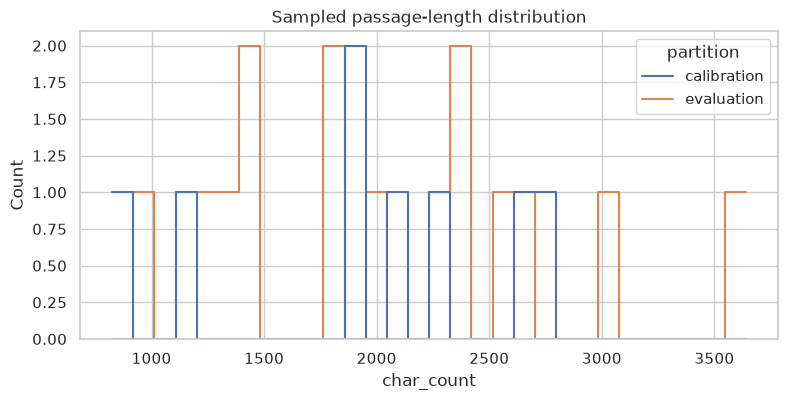

In [ ]:
dataset_info = HfApi().dataset_info(DATASET_ID)
DATASET_REVISION = dataset_info.sha
print("Pinned dataset revision:", DATASET_REVISION)
print("Using separate splits:", CALIBRATION_SPLIT, "for calibration;", EVALUATION_SPLIT, "for evaluation")

DATASET_FILES = {
    "train": (
        ["data/train-00000-of-00003.parquet"]
        if FAST_MODE
        else [
            "data/train-00000-of-00003.parquet",
            "data/train-00001-of-00003.parquet",
            "data/train-00002-of-00003.parquet",
        ]
    ),
    "test": ["data/test-00000-of-00001.parquet"],
}
downloaded_dataset_files = set()


def normalized_text_hash(text):
    normalized = " ".join(str(text).split()).casefold()
    return hashlib.sha256(normalized.encode("utf-8")).hexdigest()


def local_parquet_files(split):
    if split not in DATASET_FILES:
        raise ValueError(f"Unknown dataset split: {split}")
    paths = []
    for filename in DATASET_FILES[split]:
        target = DATASET_DIR / filename
        existed_before = target.exists()
        path = Path(
            hf_hub_download(
                repo_id=DATASET_ID,
                repo_type="dataset",
                filename=filename,
                revision=DATASET_REVISION,
                local_dir=DATASET_DIR,
            )
        )
        paths.append(str(path))
        if not existed_before:
            downloaded_dataset_files.add(path)
    return paths


def collect_candidates(split, requested_per_class, seed):
    target = max(
        requested_per_class * CANDIDATE_MULTIPLIER,
        requested_per_class + 100,
    )
    paths = local_parquet_files(split)
    counts = {0: 0, 1: 0}
    seen_hashes = set()
    rows = []
    connection = duckdb.connect()
    try:
        connection.read_parquet(paths).create_view("split_rows")
        for label in (0, 1):
            candidate_rows = connection.execute(
                """
                SELECT text, label
                FROM (
                    SELECT DISTINCT
                        trim(CAST(text AS VARCHAR)) AS text,
                        CAST(generated AS INTEGER) AS label
                    FROM split_rows
                    WHERE CAST(generated AS INTEGER) = ?
                      AND length(trim(CAST(text AS VARCHAR))) >= ?
                )
                ORDER BY hash(text || ?)
                LIMIT ?
                """,
                [label, MIN_CHARACTERS, f":seed={seed}:label={label}", target * 2],
            ).fetchall()

            for source_index, (candidate_text, candidate_label) in enumerate(candidate_rows):
                if int(candidate_label) != label:
                    raise RuntimeError("DuckDB returned an unexpected label")
                text = str(candidate_text).strip()
                text_hash = normalized_text_hash(text)
                if text_hash in seen_hashes or counts[label] >= target:
                    continue
                seen_hashes.add(text_hash)
                counts[label] += 1
                rows.append(
                    {
                        "sample_id": f"{split}:{label}:{source_index}:{text_hash[:12]}",
                        "text": text,
                        "label": label,
                        "text_hash": text_hash,
                        "char_count": len(text),
                    }
                )
    finally:
        connection.close()

    if min(counts.values()) < requested_per_class:
        raise RuntimeError(
            f"Could not collect {requested_per_class} examples per class from {split}; "
            f"got {counts}."
        )
    return pd.DataFrame(rows)


def sample_across_lengths(candidates, per_class, seed, excluded_hashes=frozenset()):
    frame = (
        candidates[~candidates.text_hash.isin(excluded_hashes)]
        .drop_duplicates("text_hash")
        .copy()
    )
    frame["length_stratum"] = pd.qcut(
        frame["char_count"],
        q=4,
        labels=False,
        duplicates="drop",
    )
    rng = np.random.default_rng(seed)
    chosen_indices = []

    for label in (0, 1):
        class_frame = frame[frame.label == label]
        strata = sorted(class_frame.length_stratum.dropna().unique())
        if not strata:
            raise RuntimeError(f"No usable length strata for label {label}")

        base_quota, remainder = divmod(per_class, len(strata))
        for position, stratum in enumerate(strata):
            group = class_frame[class_frame.length_stratum == stratum]
            quota = base_quota + int(position < remainder)
            take = min(quota, len(group))
            if take:
                chosen_indices.extend(
                    rng.choice(group.index.to_numpy(), size=take, replace=False).tolist()
                )

        selected_for_class = frame.loc[
            [index for index in chosen_indices if frame.loc[index, "label"] == label]
        ].index
        deficit = per_class - len(selected_for_class)
        if deficit:
            remaining = class_frame.drop(index=selected_for_class, errors="ignore")
            if len(remaining) < deficit:
                raise RuntimeError(
                    f"Not enough unique rows for label {label}: need {deficit} more."
                )
            chosen_indices.extend(
                rng.choice(remaining.index.to_numpy(), size=deficit, replace=False).tolist()
            )

    result = frame.loc[chosen_indices].sample(frac=1, random_state=seed).reset_index(drop=True)
    observed = result.label.value_counts().to_dict()
    assert observed == {0: per_class, 1: per_class} or observed == {1: per_class, 0: per_class}
    return result.drop(columns=["length_stratum"])


sample_cache = OUTPUT_DIR / (
    f"samples_{DATASET_REVISION[:8]}_seed{SEED}_min{MIN_CHARACTERS}_"
    f"cal{CALIBRATION_PER_CLASS}x2_eval{EVALUATION_PER_CLASS}x2.csv"
)
if sample_cache.exists() and RESUME_FROM_CHECKPOINTS:
    samples = pd.read_csv(sample_cache)
    calibration_df = samples[samples.partition == "calibration"].copy()
    evaluation_df = samples[samples.partition == "evaluation"].copy()
    print("Loaded cached samples:", sample_cache)
else:
    calibration_candidates = collect_candidates(
        CALIBRATION_SPLIT,
        CALIBRATION_PER_CLASS,
        SEED,
    )
    calibration_df = sample_across_lengths(
        calibration_candidates,
        CALIBRATION_PER_CLASS,
        SEED,
    )
    evaluation_candidates = collect_candidates(
        EVALUATION_SPLIT,
        EVALUATION_PER_CLASS,
        SEED + 1,
    )
    evaluation_df = sample_across_lengths(
        evaluation_candidates,
        EVALUATION_PER_CLASS,
        SEED + 1,
        excluded_hashes=set(calibration_df.text_hash),
    )
    calibration_df["partition"] = "calibration"
    evaluation_df["partition"] = "evaluation"
    samples = pd.concat([calibration_df, evaluation_df], ignore_index=True)
    samples.to_csv(sample_cache, index=False)
    print("Saved samples:", sample_cache)
    if DELETE_DATASET_AFTER_SAMPLING:
        for path in sorted(downloaded_dataset_files):
            if path.exists():
                path.unlink()
        print(f"Deleted {len(downloaded_dataset_files)} staged Parquet file(s)")

assert set(calibration_df.label.unique()) == {0, 1}
assert set(evaluation_df.label.unique()) == {0, 1}
assert set(calibration_df.text_hash).isdisjoint(evaluation_df.text_hash)

display(
    samples.groupby(["partition", "label"])
    .agg(n=("sample_id", "size"), median_chars=("char_count", "median"), max_chars=("char_count", "max"))
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(
    data=samples,
    x="char_count",
    hue="partition",
    bins=30,
    element="step",
    fill=False,
    ax=ax,
)
ax.set_title("Sampled passage-length distribution")
plt.show()



## Full analytic FastDetect implementation

For each observed next token \(x_t\), with model probabilities \(p(v)\), the
code accumulates:

\[
\log p(x_t), \quad
\mu_t = \sum_v p(v)\log p(v), \quad
\sigma_t^2 = \sum_v p(v)\log^2p(v)-\mu_t^2.
\]

The passage discrepancy is:

\[
d(x)=\frac{\sum_t \log p(x_t)-\sum_t\mu_t}
{\sqrt{\sum_t\sigma_t^2}}.
\]

Positive scores are more model-like. Long passages are not truncated. Each
target token is scored exactly once; later windows retain preceding context
and the final statistic is reconstructed from global sums, rather than by
averaging per-window scores.



In [ ]:
def accumulate_token_moments(logits, labels, block_rows=LOGIT_BLOCK_ROWS):
    """Return sums of observed log-p, expected log-p, and variance."""
    labels = np.asarray(labels, dtype=np.int64)
    if logits.shape[0] != labels.shape[0]:
        raise ValueError("Logit and label row counts differ")

    observed_sum = 0.0
    expected_sum = 0.0
    variance_sum = 0.0

    for start in range(0, len(labels), block_rows):
        stop = min(len(labels), start + block_rows)
        block = np.asarray(logits[start:stop], dtype=MOMENT_DTYPE)
        if not FAST_MODE and not np.isfinite(block).all():
            raise FloatingPointError("Non-finite logits")

        row_max = block.max(axis=1, keepdims=True)
        if not np.isfinite(row_max).all():
            raise FloatingPointError("Non-finite maximum logit")
        shifted = block - row_max
        exp_shifted = np.exp(shifted)
        normalizer = exp_shifted.sum(axis=1, dtype=np.float64)
        log_normalizer = np.log(normalizer)
        local_labels = labels[start:stop]
        observed = (
            shifted[np.arange(stop - start), local_labels].astype(np.float64)
            - log_normalizer
        )

        # Since log p(v) = shifted(v) - log(Z), its variance equals the
        # variance of shifted logits. This avoids materializing probability
        # and log-probability matrices over the full 128k vocabulary.
        mean_shifted = (
            (exp_shifted * shifted).sum(axis=1, dtype=np.float64) / normalizer
        )
        mean_shifted_square = (
            (exp_shifted * shifted * shifted).sum(axis=1, dtype=np.float64)
            / normalizer
        )
        expected = mean_shifted - log_normalizer
        variance = np.maximum(
            0.0,
            mean_shifted_square - mean_shifted * mean_shifted,
        )

        observed_sum += observed.sum(dtype=np.float64)
        expected_sum += expected.sum(dtype=np.float64)
        variance_sum += variance.sum(dtype=np.float64)

    return observed_sum, expected_sum, variance_sum


class FastDetectScorer:
    def __init__(
        self,
        llm,
        max_overlap=MAX_WINDOW_OVERLAP,
        max_scored_tokens=MAX_SCORED_TOKENS,
    ):
        self.llm = llm
        self.max_overlap = max_overlap
        self.max_scored_tokens = max_scored_tokens

    def tokenize(self, text):
        return self.llm.tokenize(
            str(text).encode("utf-8"),
            add_bos=True,
            special=False,
        )

    def limit_tokens(self, tokens):
        if self.max_scored_tokens is None:
            return tokens
        return tokens[: self.max_scored_tokens + 1]

    def score_tokens(self, tokens, context_length):
        started = time.perf_counter()
        if len(tokens) < 2:
            raise ValueError("At least one text token is required")
        if context_length < 3 or context_length > self.llm.n_ctx():
            raise ValueError(
                f"context_length must be in [3, {self.llm.n_ctx()}], got {context_length}"
            )

        bos_token = self.llm.token_bos()
        has_bos = bos_token >= 0 and tokens[0] == bos_token
        content_floor = 1 if has_bos else 0
        overlap = min(
            self.max_overlap,
            max(1, (context_length - 1) // 4),
            context_length - 2,
        )

        observed_sum = 0.0
        expected_sum = 0.0
        variance_sum = 0.0
        target_start = 1
        windows = 0

        while target_start < len(tokens):
            first_window = target_start == 1
            prefix_tokens = 0 if first_window or not has_bos else 1
            context_start = (
                0
                if first_window
                else max(content_floor, target_start - overlap)
            )
            content_capacity = context_length - prefix_tokens
            window_end = min(len(tokens), context_start + content_capacity)
            scored_tokens = window_end - target_start
            if scored_tokens <= 0:
                raise RuntimeError("Windowed scorer could not advance")

            window_tokens = []
            if prefix_tokens:
                window_tokens.append(bos_token)
            window_tokens.extend(tokens[context_start:window_end])

            local_target_start = (
                1
                if first_window
                else prefix_tokens + target_start - context_start
            )
            first_predictor = local_target_start - 1

            self.llm.reset()
            self.llm.eval(window_tokens)
            logits = self.llm.scores[
                first_predictor : first_predictor + scored_tokens
            ]
            labels = tokens[target_start:window_end]
            observed, expected, variance = accumulate_token_moments(logits, labels)
            observed_sum += observed
            expected_sum += expected
            variance_sum += variance

            target_start = window_end
            windows += 1

        if not np.isfinite(variance_sum) or variance_sum <= 1e-9:
            raise FloatingPointError("Discrepancy variance is zero or non-finite")
        score = (observed_sum - expected_sum) / math.sqrt(variance_sum)
        if not np.isfinite(score):
            raise FloatingPointError("Discrepancy is non-finite")

        return {
            "score": float(score),
            "token_count": len(tokens) - 1,
            "windows": windows,
            "context_overlap": overlap if windows > 1 else 0,
            "elapsed_seconds": time.perf_counter() - started,
        }

    def score_text(self, text, context_length):
        return self.score_tokens(
            self.limit_tokens(self.tokenize(text)),
            context_length,
        )


# A numerical unit test independent of any model.
toy_logits = np.array([[0.1, 1.2, -0.4], [2.0, 0.0, -1.0]], dtype=np.float32)
toy_labels = np.array([1, 0])
toy_sums = accumulate_token_moments(toy_logits, toy_labels, block_rows=1)
toy_log_probability = toy_logits.astype(np.float64)
toy_log_probability -= toy_log_probability.max(axis=1, keepdims=True)
toy_log_probability -= np.log(
    np.exp(toy_log_probability).sum(axis=1, keepdims=True)
)
toy_probability = np.exp(toy_log_probability)
toy_reference = (
    toy_log_probability[np.arange(2), toy_labels].sum(),
    (toy_probability * toy_log_probability).sum(),
    (
        (toy_probability * toy_log_probability**2).sum(axis=1)
        - (toy_probability * toy_log_probability).sum(axis=1) ** 2
    ).sum(),
)
assert np.allclose(toy_sums, toy_reference, rtol=1e-5, atol=1e-6)
print("Analytic moment test passed:", toy_sums)



Analytic moment test passed: (np.float64(-0.5982249649734991), np.float64(-1.4016989490817617), np.float64(1.106806087587156))


## Benchmark runner

A model is loaded once, every passage is tokenized once, and all requested
context policies are scored before the model is released. Per-model CSV
checkpoints make the sweep resumable.



In [ ]:
sample_columns = [
    "sample_id",
    "partition",
    "label",
    "text",
    "text_hash",
    "char_count",
]
benchmark_samples = samples[sample_columns].copy()


def model_checkpoint_path(model):
    profile = (
        f"fast_t{MAX_SCORED_TOKENS}_c{'-'.join(map(str, CONTEXT_LENGTHS))}"
        if FAST_MODE
        else "full"
    )
    return OUTPUT_DIR / f"scores_{model.model_id}_{profile}.csv"


def valid_checkpoint(frame, model):
    required = {
        "model_id",
        "sample_id",
        "partition",
        "label",
        "context_length",
        "score",
        "token_count",
    }
    if not required.issubset(frame.columns):
        return False
    if set(frame.model_id.unique()) != {model.model_id}:
        return False
    if set(frame.context_length.unique()) != set(CONTEXT_LENGTHS):
        return False
    expected_pairs = {
        (sample_id, context_length)
        for sample_id in benchmark_samples.sample_id
        for context_length in CONTEXT_LENGTHS
    }
    observed_pairs = set(zip(frame.sample_id, frame.context_length))
    return len(frame) == len(expected_pairs) and observed_pairs == expected_pairs


def score_one_model(model):
    model_started = time.perf_counter()
    checkpoint = model_checkpoint_path(model)
    if checkpoint.exists() and RESUME_FROM_CHECKPOINTS:
        cached = pd.read_csv(checkpoint)
        if valid_checkpoint(cached, model):
            print("Using checkpoint:", checkpoint.name)
            return cached
        print("Ignoring stale checkpoint:", checkpoint.name)

    free_gb = shutil.disk_usage(MODEL_DIR).free / 1e9
    if free_gb < model.size_gb + 1.0:
        raise RuntimeError(
            f"{model.label} needs about {model.size_gb:.1f} GB plus headroom; "
            f"only {free_gb:.1f} GB is free."
        )

    staged_target = MODEL_DIR / model.filename
    existed_before = staged_target.exists()
    print(f"Downloading/loading {model.label} ({model.size_gb:.2f} GB)")
    model_path = Path(
        hf_hub_download(
            repo_id=model.repo_id,
            filename=model.filename,
            local_dir=MODEL_DIR,
        )
    )

    effective_gpu_layers = (
        N_GPU_LAYERS
        if torch is not None and torch.cuda.is_available()
        else 0
    )
    llm = None
    scorer = None
    try:
        llm = Llama(
            model_path=str(model_path),
            n_ctx=BASELINE_CONTEXT,
            n_batch=BASELINE_CONTEXT,
            n_ubatch=min(N_UBATCH, BASELINE_CONTEXT),
            n_threads=N_THREADS,
            n_gpu_layers=effective_gpu_layers,
            logits_all=True,
            embedding=False,
            use_mmap=True,
            verbose=False,
        )
        scorer = FastDetectScorer(llm)
        rows = []
        iterator = tqdm(
            benchmark_samples.itertuples(index=False),
            total=len(benchmark_samples),
            desc=model.model_id,
        )
        for sample in iterator:
            base_record = {
                "model_id": model.model_id,
                "family": model.family,
                "precision": model.precision,
                "quantized": model.quantized,
                "model_label": model.label,
                "sample_id": sample.sample_id,
                "partition": sample.partition,
                "label": sample.label,
                "char_count": sample.char_count,
            }
            try:
                full_tokens = scorer.tokenize(sample.text)
                original_token_count = len(full_tokens) - 1
                tokens = scorer.limit_tokens(full_tokens)
                base_record["original_token_count"] = original_token_count
                base_record["truncated_for_speed"] = len(tokens) < len(full_tokens)
            except Exception as exc:
                for context_length in CONTEXT_LENGTHS:
                    rows.append(
                        {
                            **base_record,
                            "context_length": context_length,
                            "score": np.nan,
                            "token_count": np.nan,
                            "windows": np.nan,
                            "context_overlap": np.nan,
                            "elapsed_seconds": np.nan,
                            "error": f"tokenization: {exc!r}",
                        }
                    )
                continue

            for context_length in CONTEXT_LENGTHS:
                try:
                    result = scorer.score_tokens(tokens, context_length)
                    rows.append(
                        {
                            **base_record,
                            "context_length": context_length,
                            **result,
                            "error": "",
                        }
                    )
                except Exception as exc:
                    rows.append(
                        {
                            **base_record,
                            "context_length": context_length,
                            "score": np.nan,
                            "token_count": len(tokens) - 1,
                            "windows": np.nan,
                            "context_overlap": np.nan,
                            "elapsed_seconds": np.nan,
                            "error": repr(exc),
                        }
                    )

        frame = pd.DataFrame(rows)
        temporary = checkpoint.with_suffix(".tmp.csv")
        frame.to_csv(temporary, index=False)
        temporary.replace(checkpoint)
        print("Saved:", checkpoint)
        print(f"{model.label}: {(time.perf_counter() - model_started) / 60:.1f} min")
        return frame
    finally:
        scorer = None
        if llm is not None:
            llm.close()
            del llm
        gc.collect()
        if torch is not None and torch.cuda.is_available():
            torch.cuda.empty_cache()
        if DELETE_MODEL_AFTER_RUN and not existed_before and model_path.exists():
            model_path.unlink()
            print("Deleted staged model file:", model_path.name)


score_frames = []
model_failures = []
for model in selected_models:
    try:
        score_frames.append(score_one_model(model))
    except Exception as exc:
        model_failures.append(
            {
                **asdict(model),
                "error": repr(exc),
            }
        )
        print(f"FAILED: {model.label}: {exc}")
        if not CONTINUE_ON_MODEL_ERROR:
            raise

if not score_frames:
    raise RuntimeError("No model completed. Inspect the model_failures table.")

scores = pd.concat(score_frames, ignore_index=True)
failures_df = pd.DataFrame(model_failures)
scores.to_csv(OUTPUT_DIR / "all_scores.csv", index=False)
failures_df.to_csv(OUTPUT_DIR / "model_failures.csv", index=False)

print(f"Completed {scores.model_id.nunique()} / {len(selected_models)} selected models")
if not failures_df.empty:
    display(failures_df[["model_id", "size_gb", "error"]])



Downloading/loading Llama 3 8B Q4_K_S (4.69 GB)


Meta-Llama-3-8B.Q4_K_S.gguf: reconstructing file:   0%|          |  0.00B / 4.69GB            

Meta-Llama-3-8B.Q4_K_S.gguf: downloading bytes:           |  0.00B            

base_q4_k_s:   0%|          | 0/24 [00:00<?, ?it/s]

~llama_context:  CUDA_Host compute buffer size of  14.0538 MiB, does not match expectation of   5.2524 MiB


...

Meta-Llama-3-8B-Instruct-fp32.gguf: reconstructing file:   0%|          |  0.00B / 32.1GB            

Meta-Llama-3-8B-Instruct-fp32.gguf: downloading bytes:           |  0.00B            

instruct_fp32:   0%|          | 0/24 [00:00<?, ?it/s]

~llama_context:      CUDA0 compute buffer size of 2233.7578 MiB, does not match expectation of 2068.6250 MiB
~llama_context:  CUDA_Host compute buffer size of  14.5743 MiB, does not match expectation of   5.2524 MiB


Saved: /content/detectllama_results/scores_instruct_fp32_fast_t384_c128-512.csv
Llama 3 8B Instruct FP32: 18.9 min
Deleted staged model file: Meta-Llama-3-8B-Instruct-fp32.gguf
Completed 21 / 21 selected models


## Threshold calibration and held-out metrics

Classification uses `score >= threshold` as AI-generated. The threshold
maximizes Youden's \(J = TPR-FPR\), equivalently balanced accuracy, on the
calibration partition. No evaluation label is used to select a threshold.



In [ ]:
def binary_confusion_counts(labels, prediction):
    labels = np.asarray(labels, dtype=int)
    prediction = np.asarray(prediction, dtype=int)
    if labels.shape != prediction.shape:
        raise ValueError("Label and prediction shapes differ")
    if not set(np.unique(labels)).issubset({0, 1}):
        raise ValueError("Labels must be binary: 0 or 1")
    tn = np.sum((labels == 0) & (prediction == 0))
    fp = np.sum((labels == 0) & (prediction == 1))
    fn = np.sum((labels == 1) & (prediction == 0))
    tp = np.sum((labels == 1) & (prediction == 1))
    return int(tn), int(fp), int(fn), int(tp)


def accuracy_score(labels, prediction):
    labels = np.asarray(labels, dtype=int)
    prediction = np.asarray(prediction, dtype=int)
    return float(np.mean(labels == prediction)) if len(labels) else np.nan


def balanced_accuracy_score(labels, prediction):
    tn, fp, fn, tp = binary_confusion_counts(labels, prediction)
    if tn + fp == 0 or tp + fn == 0:
        return np.nan
    return float(0.5 * (tn / (tn + fp) + tp / (tp + fn)))


def precision_score(labels, prediction, zero_division=0):
    _, fp, _, tp = binary_confusion_counts(labels, prediction)
    return float(tp / (tp + fp)) if tp + fp else float(zero_division)


def recall_score(labels, prediction, zero_division=0):
    _, _, fn, tp = binary_confusion_counts(labels, prediction)
    return float(tp / (tp + fn)) if tp + fn else float(zero_division)


def f1_score(labels, prediction, zero_division=0):
    precision = precision_score(labels, prediction, zero_division)
    recall = recall_score(labels, prediction, zero_division)
    return (
        float(2 * precision * recall / (precision + recall))
        if precision + recall
        else float(zero_division)
    )


def roc_auc_score(labels, values):
    """Binary AUROC via average ranks, including exact handling of ties."""
    labels = np.asarray(labels, dtype=int)
    values = np.asarray(values, dtype=float)
    positive_n = int(np.sum(labels == 1))
    negative_n = int(np.sum(labels == 0))
    if positive_n == 0 or negative_n == 0:
        return np.nan

    order = np.argsort(values, kind="mergesort")
    ranks = np.empty(len(values), dtype=float)
    start = 0
    while start < len(values):
        stop = start + 1
        while stop < len(values) and values[order[stop]] == values[order[start]]:
            stop += 1
        average_rank = ((start + 1) + stop) / 2.0
        ranks[order[start:stop]] = average_rank
        start = stop

    positive_rank_sum = ranks[labels == 1].sum(dtype=np.float64)
    auc = (
        positive_rank_sum - positive_n * (positive_n + 1) / 2.0
    ) / (positive_n * negative_n)
    return float(auc)


def calibrate_threshold(labels, values):
    labels = np.asarray(labels, dtype=int)
    values = np.asarray(values, dtype=float)
    finite = np.isfinite(values)
    labels, values = labels[finite], values[finite]
    if len(np.unique(labels)) != 2:
        raise ValueError("Threshold calibration requires both classes")

    # Predictions change only at observed scores. Include an all-negative
    # candidate immediately above the maximum.
    thresholds = np.concatenate(
        ([np.nextafter(values.max(), np.inf)], np.unique(values)[::-1])
    )
    candidates = []
    for threshold in thresholds:
        prediction = (values >= threshold).astype(int)
        tn, fp, fn, tp = binary_confusion_counts(labels, prediction)
        true_positive_rate = tp / (tp + fn)
        false_positive_rate = fp / (fp + tn)
        youden_j = true_positive_rate - false_positive_rate
        candidates.append(
            (
                youden_j,
                accuracy_score(labels, prediction),
                float(threshold),
            )
        )

    # Maximize Youden J; deterministic ties prefer accuracy, then threshold.
    youden_j, _, threshold = max(candidates)
    return {
        "threshold": threshold,
        "calibration_youden_j": float(youden_j),
        "calibration_balanced_accuracy": float((1.0 + youden_j) / 2.0),
        "calibration_auroc": roc_auc_score(labels, values),
        "n_calibration": int(len(labels)),
    }


def classification_metrics(labels, values, threshold):
    labels = np.asarray(labels, dtype=int)
    values = np.asarray(values, dtype=float)
    finite = np.isfinite(values)
    labels, values = labels[finite], values[finite]
    prediction = (values >= threshold).astype(int)
    tn, fp, fn, tp = binary_confusion_counts(labels, prediction)
    return {
        "n_evaluation": int(len(labels)),
        "accuracy": accuracy_score(labels, prediction),
        "balanced_accuracy": balanced_accuracy_score(labels, prediction),
        "precision": precision_score(labels, prediction, zero_division=0),
        "recall": recall_score(labels, prediction, zero_division=0),
        "f1": f1_score(labels, prediction, zero_division=0),
        "auroc": roc_auc_score(labels, values),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }


threshold_rows = []
for (model_id, context_length), group in scores.groupby(
    ["model_id", "context_length"],
    sort=False,
):
    calibration = group[group.partition == "calibration"].dropna(subset=["score"])
    metadata = calibration.iloc[0]
    threshold_rows.append(
        {
            "model_id": model_id,
            "family": metadata.family,
            "precision": metadata.precision,
            "quantized": metadata.quantized,
            "model_label": metadata.model_label,
            "context_length": int(context_length),
            **calibrate_threshold(calibration.label, calibration.score),
        }
    )

thresholds = pd.DataFrame(threshold_rows)
baseline_thresholds = (
    thresholds[thresholds.context_length == BASELINE_CONTEXT][
        ["model_id", "threshold"]
    ]
    .rename(columns={"threshold": "baseline_threshold"})
)

metric_rows = []
for row in thresholds.itertuples(index=False):
    evaluation = scores[
        (scores.model_id == row.model_id)
        & (scores.context_length == row.context_length)
        & (scores.partition == "evaluation")
    ].dropna(subset=["score"])
    fixed_threshold = baseline_thresholds.loc[
        baseline_thresholds.model_id == row.model_id,
        "baseline_threshold",
    ].iloc[0]

    for threshold_mode, threshold in (
        ("recalibrated", row.threshold),
        ("fixed_baseline", fixed_threshold),
    ):
        metric_rows.append(
            {
                "model_id": row.model_id,
                "family": row.family,
                "precision": row.precision,
                "quantized": row.quantized,
                "model_label": row.model_label,
                "context_length": row.context_length,
                "threshold_mode": threshold_mode,
                "threshold": threshold,
                **classification_metrics(
                    evaluation.label,
                    evaluation.score,
                    threshold,
                ),
            }
        )

metrics = pd.DataFrame(metric_rows)
baseline_summary = (
    metrics[
        (metrics.context_length == BASELINE_CONTEXT)
        & (metrics.threshold_mode == "recalibrated")
    ]
    .merge(
        thresholds[thresholds.context_length == BASELINE_CONTEXT][
            [
                "model_id",
                "calibration_balanced_accuracy",
                "calibration_auroc",
                "n_calibration",
            ]
        ],
        on="model_id",
        how="left",
    )
    .sort_values(["family", "balanced_accuracy"], ascending=[True, False])
)

display(
    baseline_summary[
        [
            "model_label",
            "quantized",
            "threshold",
            "accuracy",
            "balanced_accuracy",
            "precision",
            "recall",
            "f1",
            "auroc",
            "tn",
            "fp",
            "fn",
            "tp",
        ]
    ].style.format(
        {
            "threshold": "{:.4f}",
            "accuracy": "{:.3f}",
            "balanced_accuracy": "{:.3f}",
            "precision": "{:.3f}",
            "recall": "{:.3f}",
            "f1": "{:.3f}",
            "auroc": "{:.3f}",
        }
    )
)



,model_label,quantized,threshold,accuracy,balanced_accuracy,precision,recall,f1,auroc,tn,fp,fn,tp
0,Llama 3 8B Q4_K_S,True,2.7849,0.562,0.562,1.000,0.125,0.222,0.797,8,0,7,1
1,Llama 3 8B Q4_0,True,3.0331,0.562,0.562,1.000,0.125,0.222,0.828,8,0,7,1
2,Llama 3 8B Q4_K_M,True,2.7420,0.562,0.562,1.000,0.125,0.222,0.828,8,0,7,1
3,Llama 3 8B Q4_1,True,2.2401,0.562,0.562,1.000,0.125,0.222,0.703,8,0,7,1
4,Llama 3 8B Q5_K_S,True,2.6831,0.562,0.562,1.000,0.125,0.222,0.734,8,0,7,1
5,Llama 3 8B Q5_0,True,2.7073,0.562,0.562,1.000,0.125,0.222,0.844,8,0,7,1
6,Llama 3 8B Q5_K_M,True,2.5481,0.562,0.562,1.000,0.125,0.222,0.734,8,0,7,1
7,Llama 3 8B Q5_1,True,2.5088,0.562,0.562,1.000,0.125,0.222,0.641,8,0,7,1
8,Llama 3 8B Q6_K,True,2.5653,0.562,0.562,1.000,0.125,0.222,0.719,8,0,7,1
9,Llama 3 8B Q8_0,True,2.2258,0.562,0.562,1.000,0.125,0.222,0.688,8,0,7,1


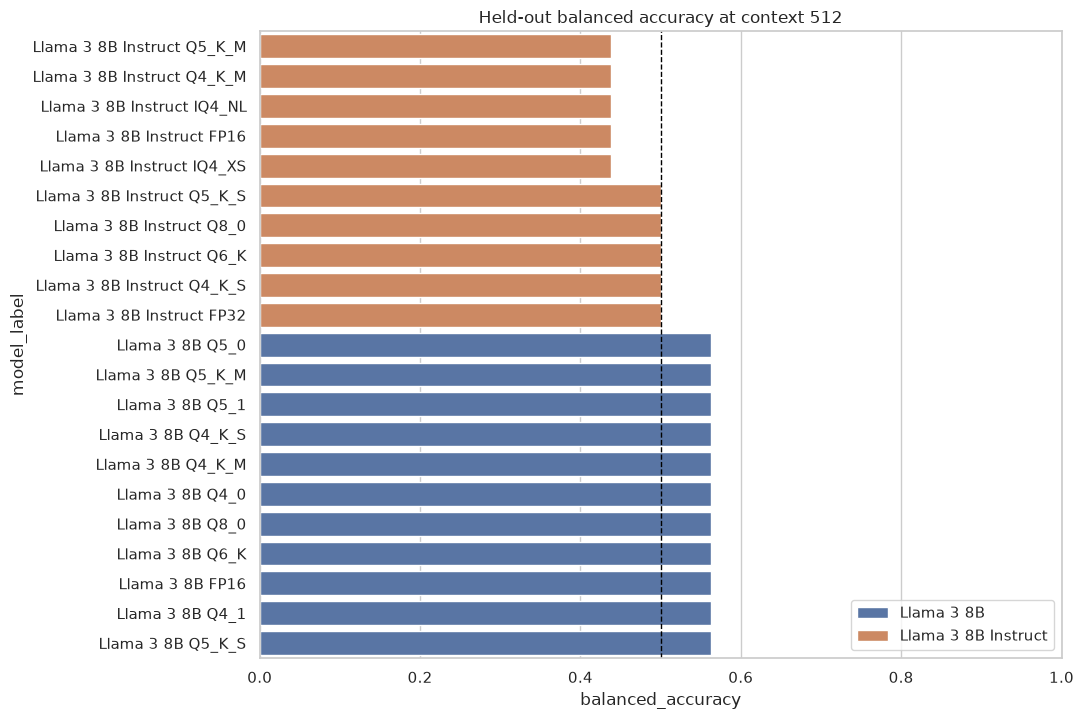

In [ ]:
fig, ax = plt.subplots(figsize=(11, max(5, 0.35 * len(baseline_summary))))
plot_order = baseline_summary.sort_values("balanced_accuracy").model_label
sns.barplot(
    data=baseline_summary,
    x="balanced_accuracy",
    y="model_label",
    hue="family",
    order=plot_order,
    dodge=False,
    ax=ax,
)
ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_xlim(0, 1)
ax.set_title(f"Held-out balanced accuracy at context {BASELINE_CONTEXT}")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "baseline_accuracy.png", dpi=160, bbox_inches="tight")
plt.show()



## Does accuracy drop for longer text?

One global baseline-context threshold is retained per model. Evaluation rows
are grouped into fixed scored-token bins. The long-minus-short trend uses the
longest and shortest token-count quartiles and a class-stratified bootstrap of
the balanced-accuracy difference:

\[
\Delta = BA_{\mathrm{long}} - BA_{\mathrm{short}}.
\]

A negative interval entirely below zero supports an accuracy drop; an interval
entirely above zero supports an improvement.



,model_id,family,precision,model_label,length_bin,n,human_n,ai_n,accuracy,balanced_accuracy
0,base_fp16,Llama 3 8B,FP16,Llama 3 8B FP16,129–256,3.0,2.0,1.0,0.666667,0.500000
1,base_fp16,Llama 3 8B,FP16,Llama 3 8B FP16,257–512,13.0,6.0,7.0,0.538462,0.571429
2,base_q4_0,Llama 3 8B,Q4_0,Llama 3 8B Q4_0,129–256,3.0,2.0,1.0,0.666667,0.500000
3,base_q4_0,Llama 3 8B,Q4_0,Llama 3 8B Q4_0,257–512,13.0,6.0,7.0,0.538462,0.571429
4,base_q4_1,Llama 3 8B,Q4_1,Llama 3 8B Q4_1,129–256,3.0,2.0,1.0,0.666667,0.500000
5,base_q4_1,Llama 3 8B,Q4_1,Llama 3 8B Q4_1,257–512,13.0,6.0,7.0,0.538462,0.571429
6,base_q4_k_m,Llama 3 8B,Q4_K_M,Llama 3 8B Q4_K_M,129–256,3.0,2.0,1.0,0.666667,0.500000
7,base_q4_k_m,Llama 3 8B,Q4_K_M,Llama 3 8B Q4_K_M,257–512,13.0,6.0,7.0,0.538462,0.571429
8,base_q4_k_s,Llama 3 8B,Q4_K_S,Llama 3 8B Q4_K_S,129–256,3.0,2.0,1.0,0.666667,0.500000
9,base_q4_k_s,Llama 3 8B,Q4_K_S,Llama 3 8B Q4_K_S,257–512,13.0,6.0,7.0,0.538462,0.571429


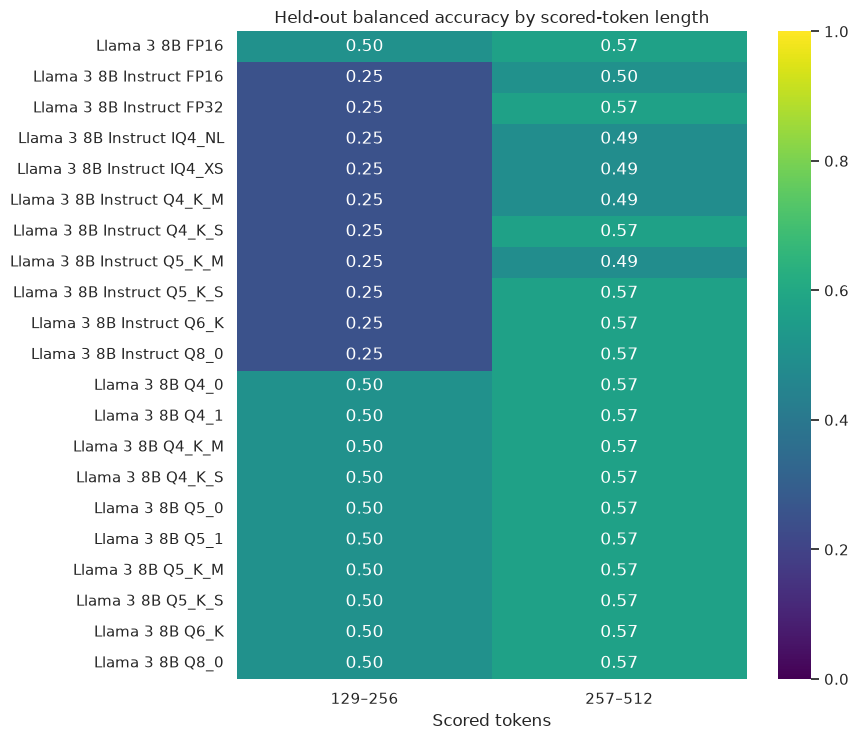

In [ ]:
baseline_eval = (
    scores[
        (scores.partition == "evaluation")
        & (scores.context_length == BASELINE_CONTEXT)
    ]
    .dropna(subset=["score", "token_count"])
    .merge(baseline_thresholds, on="model_id", how="left")
)
baseline_eval["prediction"] = (
    baseline_eval.score >= baseline_eval.baseline_threshold
).astype(int)
baseline_eval["correct"] = (baseline_eval.prediction == baseline_eval.label).astype(int)

length_edges = [0, 64, 128, 256, 512, np.inf]
length_labels = ["1–64", "65–128", "129–256", "257–512", "513+"]
baseline_eval["length_bin"] = pd.cut(
    baseline_eval.token_count,
    bins=length_edges,
    labels=length_labels,
    include_lowest=True,
)


def grouped_classification_metrics(group):
    labels = group.label.to_numpy()
    prediction = group.prediction.to_numpy()
    return pd.Series(
        {
            "n": len(group),
            "human_n": int((labels == 0).sum()),
            "ai_n": int((labels == 1).sum()),
            "accuracy": accuracy_score(labels, prediction),
            "balanced_accuracy": (
                balanced_accuracy_score(labels, prediction)
                if len(np.unique(labels)) == 2
                else np.nan
            ),
        }
    )


length_metrics = (
    baseline_eval.groupby(
        ["model_id", "family", "precision", "model_label", "length_bin"],
        observed=True,
    )
    [["label", "prediction"]]
    .apply(grouped_classification_metrics)
    .reset_index()
)
display(length_metrics)

length_pivot = length_metrics.pivot(
    index="model_label",
    columns="length_bin",
    values="balanced_accuracy",
)
fig, ax = plt.subplots(figsize=(9, max(5, 0.36 * len(length_pivot))))
sns.heatmap(
    length_pivot,
    annot=True,
    fmt=".2f",
    vmin=0,
    vmax=1,
    cmap="viridis",
    ax=ax,
)
ax.set_title("Held-out balanced accuracy by scored-token length")
ax.set_xlabel("Scored tokens")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "accuracy_by_text_length.png", dpi=160, bbox_inches="tight")
plt.show()



In [ ]:
def balanced_accuracy_from_predictions(frame):
    if frame.empty or frame.label.nunique() < 2:
        return np.nan
    return balanced_accuracy_score(frame.label, frame.prediction)


def bootstrap_balanced_accuracy_difference(short_frame, long_frame, repeats, seed):
    if (
        short_frame.label.nunique() < 2
        or long_frame.label.nunique() < 2
    ):
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    differences = np.empty(repeats, dtype=float)

    short_groups = {
        label: short_frame[short_frame.label == label]
        for label in (0, 1)
    }
    long_groups = {
        label: long_frame[long_frame.label == label]
        for label in (0, 1)
    }

    for repeat in range(repeats):
        short_draw = pd.concat(
            [
                group.iloc[rng.integers(0, len(group), len(group))]
                for group in short_groups.values()
            ]
        )
        long_draw = pd.concat(
            [
                group.iloc[rng.integers(0, len(group), len(group))]
                for group in long_groups.values()
            ]
        )
        differences[repeat] = (
            balanced_accuracy_from_predictions(long_draw)
            - balanced_accuracy_from_predictions(short_draw)
        )

    point = (
        balanced_accuracy_from_predictions(long_frame)
        - balanced_accuracy_from_predictions(short_frame)
    )
    low, high = np.quantile(differences, [0.025, 0.975])
    return float(point), float(low), float(high)


trend_rows = []
for model_number, (model_id, group) in enumerate(
    baseline_eval.groupby("model_id", sort=False)
):
    lower, upper = group.token_count.quantile([0.25, 0.75])
    short = group[group.token_count <= lower]
    long = group[group.token_count >= upper]
    difference, low, high = bootstrap_balanced_accuracy_difference(
        short,
        long,
        BOOTSTRAP_REPEATS,
        SEED + model_number,
    )
    trend_rows.append(
        {
            "model_id": model_id,
            "family": group.family.iloc[0],
            "precision": group.precision.iloc[0],
            "model_label": group.model_label.iloc[0],
            "short_max_tokens": int(lower),
            "long_min_tokens": int(upper),
            "short_n": len(short),
            "long_n": len(long),
            "short_balanced_accuracy": balanced_accuracy_from_predictions(short),
            "long_balanced_accuracy": balanced_accuracy_from_predictions(long),
            "long_minus_short": difference,
            "ci_low": low,
            "ci_high": high,
            "conclusion": (
                "drop supported"
                if high < 0
                else "improvement supported"
                if low > 0
                else "inconclusive"
            ),
        }
    )

length_trends = pd.DataFrame(trend_rows).sort_values("long_minus_short")
display(
    length_trends.style.format(
        {
            "short_balanced_accuracy": "{:.3f}",
            "long_balanced_accuracy": "{:.3f}",
            "long_minus_short": "{:+.3f}",
            "ci_low": "{:+.3f}",
            "ci_high": "{:+.3f}",
        }
    )
)

counts = length_trends.conclusion.value_counts()
print(
    "Length conclusion:",
    f"median long−short ΔBA={length_trends.long_minus_short.median():+.3f};",
    f"{counts.get('drop supported', 0)} drop(s),",
    f"{counts.get('improvement supported', 0)} improvement(s),",
    f"{counts.get('inconclusive', 0)} inconclusive.",
)



,model_id,family,precision,model_label,short_max_tokens,long_min_tokens,short_n,long_n,short_balanced_accuracy,long_balanced_accuracy,long_minus_short,ci_low,ci_high,conclusion
0,base_q4_k_s,Llama 3 8B,Q4_K_S,Llama 3 8B Q4_K_S,298,384,4,7,0.500,0.500,+0.000,+0.000,+0.000,inconclusive
1,base_q4_0,Llama 3 8B,Q4_0,Llama 3 8B Q4_0,298,384,4,7,0.500,0.500,+0.000,+0.000,+0.000,inconclusive
2,base_q4_k_m,Llama 3 8B,Q4_K_M,Llama 3 8B Q4_K_M,298,384,4,7,0.500,0.500,+0.000,+0.000,+0.000,inconclusive
3,base_q4_1,Llama 3 8B,Q4_1,Llama 3 8B Q4_1,298,384,4,7,0.500,0.500,+0.000,+0.000,+0.000,inconclusive
4,base_q5_k_s,Llama 3 8B,Q5_K_S,Llama 3 8B Q5_K_S,298,384,4,7,0.500,0.500,+0.000,+0.000,+0.000,inconclusive
5,base_q5_0,Llama 3 8B,Q5_0,Llama 3 8B Q5_0,298,384,4,7,0.500,0.500,+0.000,+0.000,+0.000,inconclusive
6,base_q5_k_m,Llama 3 8B,Q5_K_M,Llama 3 8B Q5_K_M,298,384,4,7,0.500,0.500,+0.000,+0.000,+0.000,inconclusive
7,base_q5_1,Llama 3 8B,Q5_1,Llama 3 8B Q5_1,298,384,4,7,0.500,0.500,+0.000,+0.000,+0.000,inconclusive
8,base_q6_k,Llama 3 8B,Q6_K,Llama 3 8B Q6_K,298,384,4,7,0.500,0.500,+0.000,+0.000,+0.000,inconclusive
9,base_q8_0,Llama 3 8B,Q8_0,Llama 3 8B Q8_0,298,384,4,7,0.500,0.500,+0.000,+0.000,+0.000,inconclusive


Length conclusion: median long−short ΔBA=+0.000; 0 drop(s), 0 improvement(s), 21 inconclusive.


## Effect of changing context length

Two views are important:

- **recalibrated:** each context length gets its own calibration threshold,
  measuring its best calibrated performance;
- **fixed baseline:** every context uses the threshold fitted at
  `BASELINE_CONTEXT`, measuring deployment drift if context length changes
  without recalibration.



,model_label,context_length,threshold_mode,threshold,accuracy,balanced_accuracy,auroc
41,Llama 3 8B FP16,128,fixed_baseline,2.313050,0.6250,0.6250,0.828125
43,Llama 3 8B FP16,512,fixed_baseline,2.313050,0.5625,0.5625,0.687500
40,Llama 3 8B FP16,128,recalibrated,1.891672,0.6875,0.6875,0.828125
42,Llama 3 8B FP16,512,recalibrated,2.313050,0.5625,0.5625,0.687500
77,Llama 3 8B Instruct FP16,128,fixed_baseline,-4.069619,0.4375,0.4375,0.406250
79,Llama 3 8B Instruct FP16,512,fixed_baseline,-4.069619,0.4375,0.4375,0.406250
76,Llama 3 8B Instruct FP16,128,recalibrated,-1.870645,0.5000,0.5000,0.406250
78,Llama 3 8B Instruct FP16,512,recalibrated,-4.069619,0.4375,0.4375,0.406250
81,Llama 3 8B Instruct FP32,128,fixed_baseline,-5.145419,0.5625,0.5625,0.437500
83,Llama 3 8B Instruct FP32,512,fixed_baseline,-5.145419,0.5000,0.5000,0.484375


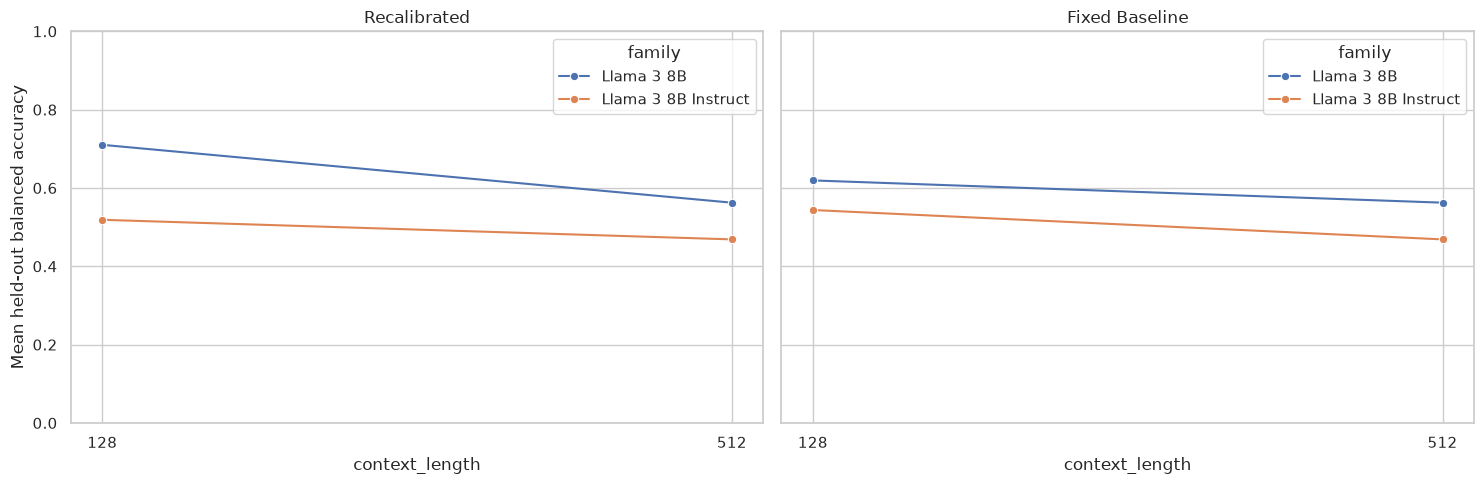

In [ ]:
display(
    metrics[
        [
            "model_label",
            "context_length",
            "threshold_mode",
            "threshold",
            "accuracy",
            "balanced_accuracy",
            "auroc",
        ]
    ].sort_values(["model_label", "threshold_mode", "context_length"])
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, mode in zip(axes, ["recalibrated", "fixed_baseline"]):
    family_context = (
        metrics[metrics.threshold_mode == mode]
        .groupby(["family", "context_length"], as_index=False)
        .agg(
            mean_balanced_accuracy=("balanced_accuracy", "mean"),
            sd_balanced_accuracy=("balanced_accuracy", "std"),
        )
    )
    sns.lineplot(
        data=family_context,
        x="context_length",
        y="mean_balanced_accuracy",
        hue="family",
        marker="o",
        ax=ax,
    )
    ax.set_xscale("log", base=2)
    ax.set_xticks(CONTEXT_LENGTHS, labels=CONTEXT_LENGTHS)
    ax.set_ylim(0, 1)
    ax.set_title(mode.replace("_", " ").title())
    ax.set_ylabel("Mean held-out balanced accuracy")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "accuracy_by_context.png", dpi=160, bbox_inches="tight")
plt.show()



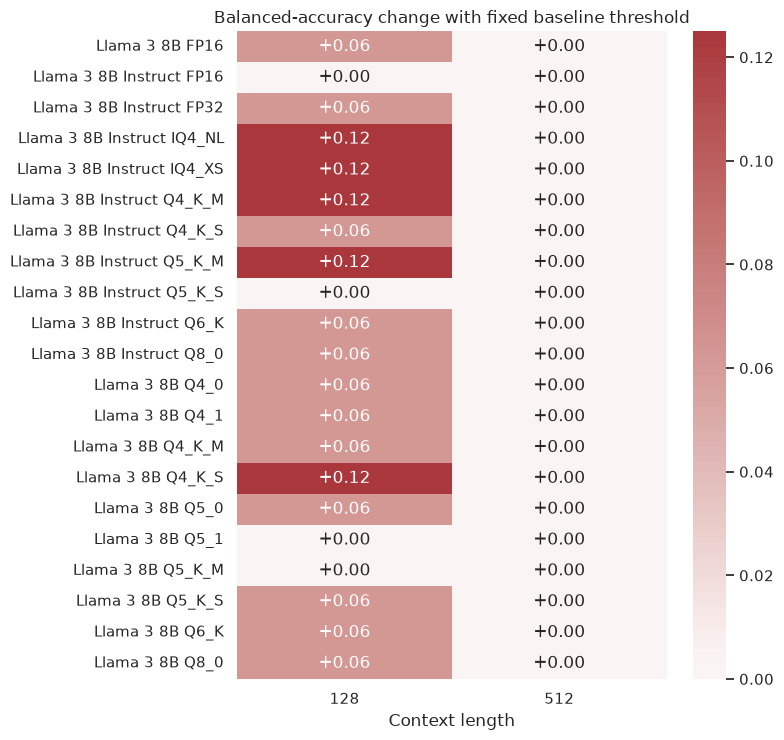

context_length,model_id,model_label,threshold_mode,128,512,baseline_minus_shortest
8,base_q4_k_s,Llama 3 8B Q4_K_S,fixed_baseline,0.6875,0.5625,-0.1250
26,instruct_iq4_nl,Llama 3 8B Instruct IQ4_NL,fixed_baseline,0.5625,0.4375,-0.1250
28,instruct_iq4_xs,Llama 3 8B Instruct IQ4_XS,fixed_baseline,0.5625,0.4375,-0.1250
30,instruct_q4_k_m,Llama 3 8B Instruct Q4_K_M,fixed_baseline,0.5625,0.4375,-0.1250
34,instruct_q5_k_m,Llama 3 8B Instruct Q5_K_M,fixed_baseline,0.5625,0.4375,-0.1250
0,base_fp16,Llama 3 8B FP16,fixed_baseline,0.6250,0.5625,-0.0625
2,base_q4_0,Llama 3 8B Q4_0,fixed_baseline,0.6250,0.5625,-0.0625
4,base_q4_1,Llama 3 8B Q4_1,fixed_baseline,0.6250,0.5625,-0.0625
6,base_q4_k_m,Llama 3 8B Q4_K_M,fixed_baseline,0.6250,0.5625,-0.0625
10,base_q5_0,Llama 3 8B Q5_0,fixed_baseline,0.6250,0.5625,-0.0625


fixed_baseline: mean BA(512)−BA(128) = -0.065; median = -0.062
recalibrated: mean BA(512)−BA(128) = -0.101; median = -0.062


In [ ]:
fixed_context = metrics[metrics.threshold_mode == "fixed_baseline"].copy()
fixed_baseline_values = (
    fixed_context[fixed_context.context_length == BASELINE_CONTEXT][
        ["model_id", "balanced_accuracy"]
    ]
    .rename(columns={"balanced_accuracy": "baseline_balanced_accuracy"})
)
fixed_context = fixed_context.merge(fixed_baseline_values, on="model_id")
fixed_context["delta_from_baseline"] = (
    fixed_context.balanced_accuracy - fixed_context.baseline_balanced_accuracy
)

context_delta_pivot = fixed_context.pivot(
    index="model_label",
    columns="context_length",
    values="delta_from_baseline",
)
fig, ax = plt.subplots(figsize=(8, max(5, 0.36 * len(context_delta_pivot))))
sns.heatmap(
    context_delta_pivot,
    annot=True,
    fmt="+.2f",
    center=0,
    cmap="vlag",
    ax=ax,
)
ax.set_title("Balanced-accuracy change with fixed baseline threshold")
ax.set_xlabel("Context length")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "context_delta_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

shortest = min(CONTEXT_LENGTHS)
context_conclusion = (
    metrics[metrics.context_length.isin([shortest, BASELINE_CONTEXT])]
    .pivot_table(
        index=["model_id", "model_label", "threshold_mode"],
        columns="context_length",
        values="balanced_accuracy",
    )
    .reset_index()
)
context_conclusion["baseline_minus_shortest"] = (
    context_conclusion[BASELINE_CONTEXT] - context_conclusion[shortest]
)
display(context_conclusion.sort_values(["threshold_mode", "baseline_minus_shortest"]))

for mode, group in context_conclusion.groupby("threshold_mode"):
    print(
        f"{mode}: mean BA({BASELINE_CONTEXT})−BA({shortest}) = "
        f"{group.baseline_minus_shortest.mean():+.3f}; "
        f"median = {group.baseline_minus_shortest.median():+.3f}"
    )



## Export reproducible artifacts



In [ ]:
thresholds.to_csv(OUTPUT_DIR / "thresholds.csv", index=False)
metrics.to_csv(OUTPUT_DIR / "metrics_by_context.csv", index=False)
baseline_summary.to_csv(OUTPUT_DIR / "baseline_model_summary.csv", index=False)
length_metrics.to_csv(OUTPUT_DIR / "metrics_by_text_length.csv", index=False)
length_trends.to_csv(OUTPUT_DIR / "text_length_trends.csv", index=False)
context_conclusion.to_csv(OUTPUT_DIR / "context_conclusions.csv", index=False)

run_metadata = {
    "seed": SEED,
    "fast_mode": FAST_MODE,
    "dataset_id": DATASET_ID,
    "dataset_revision": DATASET_REVISION,
    "calibration_split": CALIBRATION_SPLIT,
    "evaluation_split": EVALUATION_SPLIT,
    "calibration_per_class": CALIBRATION_PER_CLASS,
    "evaluation_per_class": EVALUATION_PER_CLASS,
    "context_lengths": CONTEXT_LENGTHS,
    "baseline_context": BASELINE_CONTEXT,
    "max_scored_tokens": MAX_SCORED_TOKENS,
    "moment_dtype": np.dtype(MOMENT_DTYPE).name,
    "max_window_overlap": MAX_WINDOW_OVERLAP,
    "models_requested": [model.model_id for model in selected_models],
    "models_completed": sorted(scores.model_id.unique().tolist()),
    "threshold_rule": "score >= threshold; maximize calibration Youden J",
    "length_delta": "longest evaluation quartile BA minus shortest quartile BA",
}
(OUTPUT_DIR / "run_metadata.json").write_text(
    json.dumps(run_metadata, indent=2),
    encoding="utf-8",
)

archive = shutil.make_archive(
    str(OUTPUT_DIR),
    "zip",
    root_dir=OUTPUT_DIR,
)
print("Artifacts:", OUTPUT_DIR.resolve())
print("ZIP archive:", archive)
print(sorted(path.name for path in OUTPUT_DIR.iterdir()))



Artifacts: /content/detectllama_results
ZIP archive: /content/detectllama_results.zip
['accuracy_by_context.png', 'accuracy_by_text_length.png', 'all_scores.csv', 'baseline_accuracy.png', 'baseline_model_summary.csv', 'context_conclusions.csv', 'context_delta_heatmap.png', 'metrics_by_context.csv', 'metrics_by_text_length.csv', 'model_failures.csv', 'run_metadata.json', 'samples_0387d82c_seed20260730_min100_cal30x2_eval60x2.csv', 'samples_0387d82c_seed20260730_min100_cal4x2_eval8x2.csv', 'scores_base_fp16_fast_t384_c128-512.csv', 'scores_base_q4_0_fast_t384_c128-512.csv', 'scores_base_q4_1_fast_t384_c128-512.csv', 'scores_base_q4_k_m_fast_t384_c128-512.csv', 'scores_base_q4_k_s_fast_t384_c128-512.csv', 'scores_base_q5_0_fast_t384_c128-512.csv', 'scores_base_q5_1_fast_t384_c128-512.csv', 'scores_base_q5_k_m_fast_t384_c128-512.csv', 'scores_base_q5_k_s_fast_t384_c128-512.csv', 'scores_base_q6_k_fast_t384_c128-512.csv', 'scores_base_q8_0_fast_t384_c128-512.csv', 'scores_instruct_fp16_fast

## Interpretation checklist

- Con `FAST_MODE=True`, soglie e accuracy sono stime esplorative su un campione
  piccolo e sui primi 384 token. Non usarle come valori di produzione.
- Use `baseline_model_summary.csv` for the primary per-quantization comparison.
- Use `text_length_trends.csv` to answer whether longer text lowers accuracy.
  Treat `inconclusive` as insufficient evidence, not as proof of no effect.
- Use `metrics_by_context.csv` to compare recalibrated and fixed-threshold
  context changes.
- Inspect class-specific recall and confusion counts, not accuracy alone.
- Increase sample sizes before making a strong claim. With small samples,
  estimates and bootstrap intervals are intentionally exploratory.
- These labels combine heterogeneous human and AI sources. Report results as
  performance on this dataset revision, not as a universal detector benchmark.
